# MVP v0.2.5.7: Action Log-Prob Diagnostic — Is Guidance Working?

**Date:** 2026-03-13
**Builds on:** v0.2.5.5 (corrected guidance, marginal OPE improvement)

## Goal

Determine whether positive guidance actually steers synthetic trajectory actions
toward the target policy, using **action noise prediction error** as a proxy for
log-probability under the target policy.

**Key insight:** MSE vs real trajectories and OPE error are poor diagnostics for
single-policy guidance because (1) MSE requires pointwise trajectory alignment which
fails for stochastic policies, and (2) OPE error conflates trajectory quality with
reward accuracy.

**Method:**
1. Generate trajectories with and without guidance (same seeds, same initial states)
2. For each trajectory, compute noise prediction error under the target policy
3. Lower error = actions more likely under target = guidance is working

**Success criterion:**
- Guided trajectories have significantly lower action NLL proxy than unguided
- Wilcoxon signed-rank p < 0.05 on paired comparison
- >70% of trajectories show improvement

**Settings from v0.2.5.1-v0.2.5.5 learnings:**
- `score_timestep=5` (sigma=0.105, sweet spot from v0.2.5.4)
- `action_scale in [0.0003, 0.001, 0.005, 0.01]` (corrected from v0.2.5.3)
- `normalize_grad=True`
- 50 trajectories, T_GEN=60

In [1]:
%matplotlib inline
import sys, os, importlib
import numpy as np
import torch
import torch.nn as nn
import h5py, json, math, time
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils

import latent_sope.robomimic_interface.guidance as _guidance_mod
importlib.reload(_guidance_mod)
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_algo_from_checkpoint
)
from latent_sope.robomimic_interface.guidance import RobomimicDiffusionScorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
CKPT_DIR = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models/test/20260309132349"
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
TARGET_ROLLOUT_DIR = PROJECT_ROOT / "rollouts" / "target_policy_50"
DIFFUSION_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0252_traj_mse"
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

# Dims
STATE_DIM = 19
ACTION_DIM = 7
TRANSITION_DIM = 26
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84

# Diffuser config (must match v0.2.5.2 training)
CHUNK_SIZE = 4
N_DIFFUSION_STEPS = 256
BASE_DIM = 32
DIM_MULTS = (1, 4, 8)
ACTION_WEIGHT = 5.0

# Generation config
NUM_SYNTHETIC = 50
T_GEN = 60

# Guidance config (from v0.2.5.3/v0.2.5.4 learnings)
SCORE_TIMESTEP = 5

# Sweep: unguided + 4 pos-only scales
GUIDANCE_CONFIGS = [
    {"action_scale": 0.0,    "label": "unguided"},
    {"action_scale": 0.0003, "label": "pos_0.0003"},
    {"action_scale": 0.001,  "label": "pos_0.001"},
    {"action_scale": 0.005,  "label": "pos_0.005"},
    {"action_scale": 0.01,   "label": "pos_0.01"},
]

# NLL proxy config
N_NOISE_SAMPLES = 10
NLL_CHUNK_SIZE = CHUNK_SIZE

print(f"score_timestep={SCORE_TIMESTEP}, {len(GUIDANCE_CONFIGS)} configs")
print(f"{NUM_SYNTHETIC} trajs, T_GEN={T_GEN}")
print(f"NLL proxy: {N_NOISE_SAMPLES} noise samples, chunk_size={NLL_CHUNK_SIZE}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda
score_timestep=5, 5 configs
50 trajs, T_GEN=60
NLL proxy: 10 noise samples, chunk_size=4


In [2]:
# ── Load checkpoint, oracle, target rollouts, expert demos ──
ckpt = load_checkpoint(CKPT_DIR, ckpt_path=Path("last.pth"))
target_algo = build_algo_from_checkpoint(ckpt, device=str(device))

with open(CKPT_DIR / "oracle_50.json", "r") as f:
    oracle_data = json.load(f)
oracle_value = float(oracle_data["mean_return"])
oracle_sr = float(np.mean(np.array(oracle_data["returns"]) > 0.5))
print(f"Oracle V^pi = {oracle_value:.4f}, SR = {oracle_sr*100:.0f}%")

# Target rollouts
target_data = []
all_states_list, all_actions_list = [], []
for path in sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:50]:
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
        actions = f["actions"][:]
    states = (latents[:, -1, :] if latents.ndim == 3 else latents).astype(np.float32)
    actions = actions.astype(np.float32)
    target_data.append({"states": states, "actions": actions})
    all_states_list.append(states)
    all_actions_list.append(actions)
print(f"Loaded {len(target_data)} target rollouts")

# Expert demos
with h5py.File(DEMO_HDF5, "r") as f:
    for dk in sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1])):
        demo = f[f"data/{dk}"]
        states = np.concatenate([demo["obs"][k][:].astype(np.float32) for k in OBS_KEYS], axis=-1)
        actions = demo["actions"][:].astype(np.float32)
        all_states_list.append(states)
        all_actions_list.append(actions)
print(f"Loaded 200 expert demos")

# Normalization (same as v0.2.5.2 training)
all_states = np.concatenate(all_states_list, axis=0)
all_actions = np.concatenate(all_actions_list, axis=0)
norm_mean = np.concatenate([all_states.mean(0), all_actions.mean(0)]).astype(np.float32)
norm_std = np.maximum(np.concatenate([all_states.std(0), all_actions.std(0)]), 1e-6).astype(np.float32)
norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

# Initial states for generation
initial_states_t = torch.tensor(
    np.array([ep["states"][0] for ep in target_data[:NUM_SYNTHETIC]]),
    dtype=torch.float32, device=device
)
print(f"Initial states: {initial_states_t.shape}")


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['object', 'robot0_eef_quat', 'robot0_eef_pos', 'robot0_gripper_qpos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[17:49:21] INFO     build_algo_from_checkpoint took 0.48 seconds to execute                           ]8;id=668145;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=295221;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

Oracle V^pi = 0.5400, SR = 54%
Loaded 50 target rollouts


Loaded 200 expert demos
Initial states: torch.Size([50, 19])


In [3]:
# ── Load pre-trained diffuser ──
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE, transition_dim=TRANSITION_DIM,
    dim=BASE_DIM, dim_mults=DIM_MULTS, attention=False,
).to(device)
diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM, action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
    predict_epsilon=False, loss_type="l2",
    clip_denoised=False, action_weight=ACTION_WEIGHT,
).to(device)
ema = EMA(diffusion_model)
ema.ema_model.load_state_dict(
    torch.load(DIFFUSION_SAVE_DIR / "diffusion_model_ema.pt", map_location=device)
)
print(f"Loaded EMA diffuser from {DIFFUSION_SAVE_DIR}")

# ── Target scorer ──
target_scorer = RobomimicDiffusionScorer(
    target_algo, device=str(device), score_timestep=SCORE_TIMESTEP, obs_keys=OBS_KEYS
)
print(f"Target scorer: score_timestep={SCORE_TIMESTEP}, sigma={target_scorer.sigma:.4f}")

[ models/temporal ] Channel dimensions: [(26, 32), (32, 128), (128, 256)]
[(26, 32), (32, 128), (128, 256)]
Loaded EMA diffuser from /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v0252_traj_mse
Target scorer: score_timestep=5, sigma=0.1050


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


In [4]:
def generate_trajectories(
    diffusion_model, initial_states,
    normalize_fn, unnormalize_fn,
    state_dim, action_dim, chunk_size, t_gen, device,
    target_scorer=None, action_scale=0.0, normalize_grad=True,
):
    """Generate synthetic trajectories with optional pos-only guidance."""
    guided = (target_scorer is not None and action_scale > 0)
    B = initial_states.shape[0]
    td = state_dim + action_dim
    n_ts = diffusion_model.n_timesteps

    pad = torch.cat([initial_states, torch.zeros(B, action_dim, device=device)], 1)
    cond_init = normalize_fn(pad)[:, :state_dim]
    all_traj = torch.zeros(B, t_gen, td, device=device)
    conditions = {0: cond_init}
    total = 0

    while total < t_gen:
        x = torch.randn(B, chunk_size, td, device=device)
        x = apply_conditioning(x, conditions, state_dim)

        for t_d in reversed(range(n_ts)):
            t_t = torch.full((B,), t_d, device=device, dtype=torch.long)
            with torch.no_grad():
                mm, _, mlv = diffusion_model.p_mean_variance(x=x, t=t_t)
                ms = torch.exp(0.5 * mlv)

            if guided:
                mm = unnormalize_fn(mm)
                sc = mm[:, :, :state_dim]
                ac = mm[:, :, state_dim:]
                tg = target_scorer.grad_log_prob_chunk(sc, ac)
                if normalize_grad:
                    tg = tg / (tg.norm(dim=-1, keepdim=True) + 1e-6)
                guide = torch.zeros_like(mm)
                guide[:, :, state_dim:] = tg
                mm = mm + action_scale * guide
                mm = normalize_fn(mm)
                mm = apply_conditioning(mm, conditions, state_dim)
                mm = unnormalize_fn(mm)
                mm = normalize_fn(mm)

            noise = torch.randn_like(x)
            x = mm + (1 - (t_d == 0) * 1.0) * ms * noise
            x = apply_conditioning(x, conditions, state_dim)

        chunk_u = unnormalize_fn(x)
        n_store = min(chunk_size - 1, t_gen - total)
        all_traj[:, total:total+n_store] = chunk_u[:, :n_store]
        total += n_store
        if total >= t_gen:
            break
        conditions = {0: x[:, -1, :state_dim]}

    return all_traj.detach().cpu().numpy()

print("Generator ready.")

Generator ready.


In [5]:
@torch.no_grad()
def compute_action_nll_proxy(scorer, states, actions, chunk_size=4, n_samples=10):
    """
    Compute noise prediction error as proxy for action NLL under target policy.

    For each chunk of (state, action) pairs:
    1. Build obs conditioning from states
    2. Place actions in Tp-length sequence via scorer infrastructure
    3. Add noise at score_timestep level
    4. Predict noise with target policy's noise pred net
    5. MSE(true_noise, pred_noise) is proportional to -log p(action|state)

    Lower error = higher likelihood under target policy.

    Returns:
        per_chunk_nll: (B, n_chunks) noise prediction error per chunk
        per_traj_nll: (B,) mean error per trajectory
    """
    B, T, _ = states.shape
    dev = scorer.device

    alpha_bar = scorer.noise_scheduler.alphas_cumprod[scorer.score_timestep].to(dev)
    sqrt_ab = alpha_bar.sqrt()
    sqrt_1mab = (1 - alpha_bar).sqrt()

    chunk_errors = []

    for start in range(0, T - chunk_size + 1, chunk_size):
        s_chunk = states[:, start:start+chunk_size].to(dev)
        a_chunk = actions[:, start:start+chunk_size].to(dev)

        # Build conditioning and action sequence using scorer's infrastructure
        obs_cond = scorer._build_obs_conditioning(s_chunk)
        action_seq = scorer._build_action_sequence(a_chunk)  # (B, Tp, ad)

        chunk_err = torch.zeros(B, device=dev)
        for _ in range(n_samples):
            eps = torch.randn_like(action_seq)
            x_t = sqrt_ab * action_seq + sqrt_1mab * eps
            t_tensor = torch.full((B,), scorer.score_timestep, device=dev, dtype=torch.long)
            eps_pred = scorer.noise_pred_net(sample=x_t, timestep=t_tensor, global_cond=obs_cond)

            # Error at chunk positions only
            cs = scorer._action_start
            ce = min(cs + chunk_size, scorer.prediction_horizon)
            err = ((eps[:, cs:ce] - eps_pred[:, cs:ce]) ** 2).mean(dim=(1, 2))  # (B,)
            chunk_err += err

        chunk_errors.append(chunk_err / n_samples)

    per_chunk = torch.stack(chunk_errors, dim=1)  # (B, n_chunks)
    per_traj = per_chunk.mean(dim=1)  # (B,)

    return per_chunk.cpu().numpy(), per_traj.cpu().numpy()

print("NLL proxy function ready.")

NLL proxy function ready.


In [6]:
# ── Generate trajectories + compute NLL proxy for each config ──
results = {}
t0_all = time.time()

for i, gc in enumerate(GUIDANCE_CONFIGS):
    label = gc["label"]
    asc = gc["action_scale"]
    is_unguided = (asc == 0.0)

    print(f"\n[{i+1}/{len(GUIDANCE_CONFIGS)}] {label}")

    # Reset seed for fair paired comparison
    np.random.seed(42)
    torch.manual_seed(42)

    # Generate trajectories
    t0 = time.time()
    trajs = generate_trajectories(
        diffusion_model=ema.ema_model,
        initial_states=initial_states_t,
        normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
        state_dim=STATE_DIM, action_dim=ACTION_DIM,
        chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
        target_scorer=target_scorer if not is_unguided else None,
        action_scale=asc, normalize_grad=True,
    )
    gen_time = time.time() - t0

    ss = trajs[:, :, :STATE_DIM]
    sa = trajs[:, :, STATE_DIM:]

    # Compute NLL proxy
    t0 = time.time()
    per_chunk_nll, per_traj_nll = compute_action_nll_proxy(
        target_scorer,
        torch.tensor(ss, dtype=torch.float32),
        torch.tensor(sa, dtype=torch.float32),
        chunk_size=NLL_CHUNK_SIZE, n_samples=N_NOISE_SAMPLES,
    )
    nll_time = time.time() - t0

    # Secondary: SR
    synth_sr = np.mean([np.any(ss[j, :, CUBE_Z_INDEX] > LIFT_THRESHOLD)
                        for j in range(NUM_SYNTHETIC)])

    results[label] = {
        "action_scale": asc,
        "synth_states": ss,
        "synth_actions": sa,
        "per_chunk_nll": per_chunk_nll,
        "per_traj_nll": per_traj_nll,
        "mean_nll": float(per_traj_nll.mean()),
        "std_nll": float(per_traj_nll.std()),
        "synth_sr": synth_sr,
        "gen_time": gen_time,
        "nll_time": nll_time,
    }

    print(f"  Gen: {gen_time:.0f}s, NLL: {nll_time:.0f}s")
    print(f"  Mean NLL proxy: {per_traj_nll.mean():.6f} +/- {per_traj_nll.std():.6f}")
    print(f"  SR: {synth_sr*100:.0f}%")

total_time = time.time() - t0_all
print(f"\nTotal time: {total_time:.0f}s ({total_time/60:.1f} min)")


[1/5] unguided


  Gen: 62s, NLL: 3s
  Mean NLL proxy: 0.313762 +/- 0.096117
  SR: 60%

[2/5] pos_0.0003


  Gen: 121s, NLL: 3s
  Mean NLL proxy: 0.308232 +/- 0.097461
  SR: 58%

[3/5] pos_0.001


  Gen: 120s, NLL: 3s
  Mean NLL proxy: 0.311870 +/- 0.103427
  SR: 62%

[4/5] pos_0.005


  Gen: 120s, NLL: 3s
  Mean NLL proxy: 0.302536 +/- 0.112197
  SR: 46%

[5/5] pos_0.01


  Gen: 120s, NLL: 3s
  Mean NLL proxy: 0.287350 +/- 0.096784
  SR: 50%

Total time: 556s (9.3 min)


In [7]:
# ── Statistical tests: paired comparison vs unguided ──
print(f"{'='*90}")
print(f"v0.2.5.7 ACTION LOG-PROB DIAGNOSTIC")
print(f"score_timestep={SCORE_TIMESTEP}, sigma={target_scorer.sigma:.4f}")
print(f"{'='*90}")

unguided_nll = results["unguided"]["per_traj_nll"]

print(f"\n{'Config':<14} {'Mean NLL':>10} {'Std':>10} "
      f"{'vs Unguided':>12} {'Win%':>6} {'Wilcoxon p':>11} {'SR':>5}")
print("-" * 80)

for label, r in results.items():
    nll = r["per_traj_nll"]
    mean_nll = nll.mean()
    std_nll = nll.std()

    if label == "unguided":
        print(f"{label:<14} {mean_nll:>10.6f} {std_nll:>10.6f} "
              f"{'(baseline)':>12} {'--':>6} {'--':>11} {r['synth_sr']*100:>4.0f}%")
        continue

    # Paired difference: positive = guidance helped (lower NLL)
    diff = unguided_nll - nll
    win_pct = np.mean(diff > 0) * 100

    # Wilcoxon signed-rank test (one-sided: guided < unguided)
    _, p_one = stats.wilcoxon(unguided_nll, nll, alternative='greater')

    delta_pct = (mean_nll - unguided_nll.mean()) / unguided_nll.mean() * 100

    sig = "***" if p_one < 0.001 else "**" if p_one < 0.01 else "*" if p_one < 0.05 else ""

    print(f"{label:<14} {mean_nll:>10.6f} {std_nll:>10.6f} "
          f"{delta_pct:>+10.1f}% {win_pct:>5.0f}% {p_one:>10.4f} {sig:<1} {r['synth_sr']*100:>4.0f}%")

print(f"\n{'='*90}")
print("Interpretation:")
print("  Lower NLL proxy = actions more likely under target policy = guidance working")
print("  Win% = fraction of trajectories where guided NLL < unguided NLL")
print("  * p<0.05, ** p<0.01, *** p<0.001 (one-sided Wilcoxon)")

# Effect size (Cohen's d) for best config
best_label = min([l for l in results if l != "unguided"],
                  key=lambda l: results[l]["mean_nll"])
best_diff = unguided_nll - results[best_label]["per_traj_nll"]
cohens_d = best_diff.mean() / best_diff.std()
print(f"\nBest config: {best_label}")
print(f"  Cohen's d = {cohens_d:.3f} "
      f"({'large' if abs(cohens_d) > 0.8 else 'medium' if abs(cohens_d) > 0.5 else 'small'})")

v0.2.5.7 ACTION LOG-PROB DIAGNOSTIC
score_timestep=5, sigma=0.1050

Config           Mean NLL        Std  vs Unguided   Win%  Wilcoxon p    SR
--------------------------------------------------------------------------------
unguided         0.313762   0.096117   (baseline)     --          --   60%


pos_0.0003       0.308232   0.097461       -1.8%    70%     0.0030 **   58%
pos_0.001        0.311870   0.103427       -0.6%    54%     0.2512     62%
pos_0.005        0.302536   0.112197       -3.6%    68%     0.0354 *   46%
pos_0.01         0.287350   0.096784       -8.4%    70%     0.0604     50%

Interpretation:
  Lower NLL proxy = actions more likely under target policy = guidance working
  Win% = fraction of trajectories where guided NLL < unguided NLL
  * p<0.05, ** p<0.01, *** p<0.001 (one-sided Wilcoxon)

Best config: pos_0.01
  Cohen's d = 0.238 (small)


/tmp/ipykernel_1560221/1116857244.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data, labels=labels, patch_artist=True, showmeans=True,


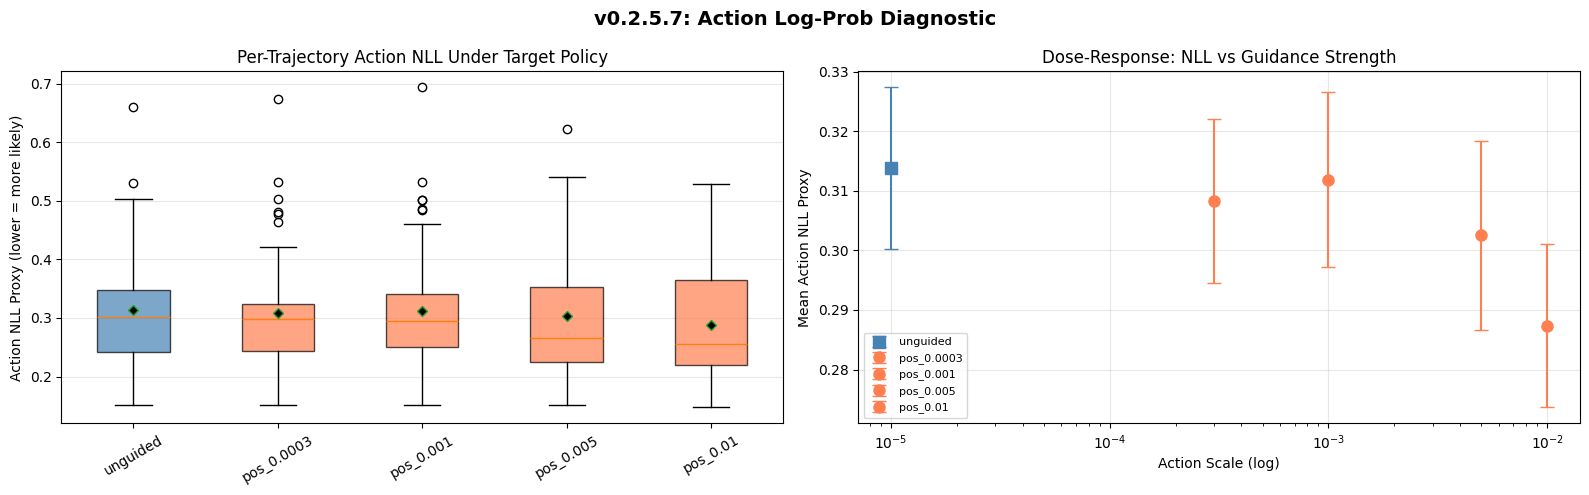

In [8]:
# ── Figure 1: NLL proxy distribution per config ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Box plot of per-trajectory NLL
labels = list(results.keys())
data = [results[l]["per_traj_nll"] for l in labels]
colors_list = ["steelblue" if l == "unguided" else "coral" for l in labels]

bp = axes[0].boxplot(data, labels=labels, patch_artist=True, showmeans=True,
                      meanprops=dict(marker='D', markerfacecolor='black', markersize=5))
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel("Action NLL Proxy (lower = more likely)")
axes[0].set_title("Per-Trajectory Action NLL Under Target Policy")
axes[0].grid(True, alpha=0.3, axis="y")
axes[0].tick_params(axis='x', rotation=30)

# Panel 2: Mean NLL vs action scale (dose-response)
scales = [max(r["action_scale"], 1e-5) for r in results.values()]
means = [r["mean_nll"] for r in results.values()]
sems = [r["std_nll"] / np.sqrt(NUM_SYNTHETIC) for r in results.values()]

ax2 = axes[1]
for s, m, se, l in zip(scales, means, sems, labels):
    color = "steelblue" if l == "unguided" else "coral"
    marker = "s" if l == "unguided" else "o"
    ax2.errorbar(s, m, yerr=se, fmt=marker, color=color,
                 markersize=8, capsize=5, label=l)
ax2.set_xscale("log")
ax2.set_xlabel("Action Scale (log)")
ax2.set_ylabel("Mean Action NLL Proxy")
ax2.set_title("Dose-Response: NLL vs Guidance Strength")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle("v0.2.5.7: Action Log-Prob Diagnostic", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

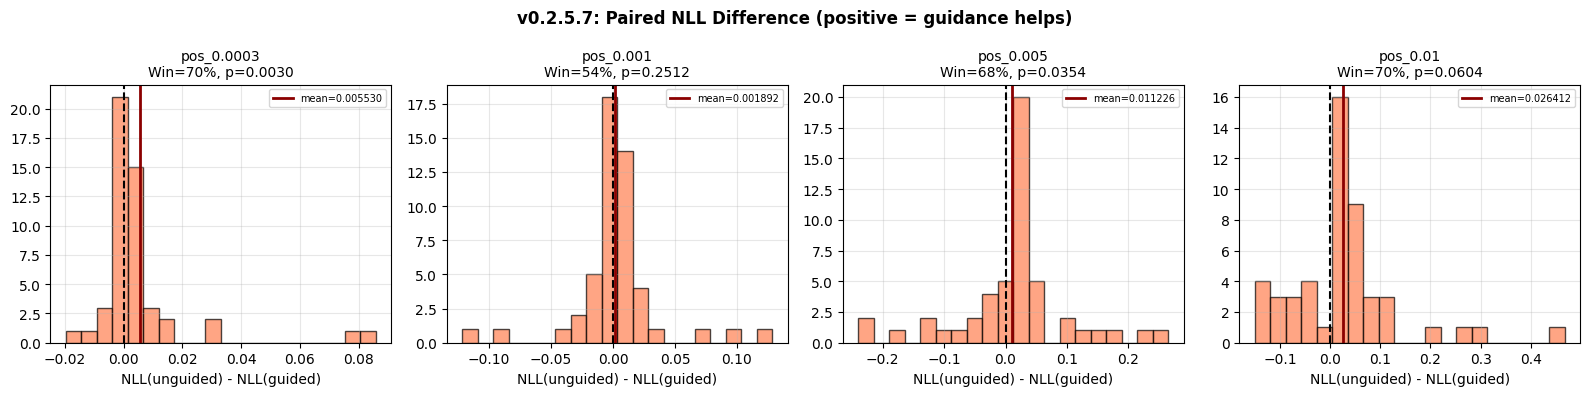

In [9]:
# ── Figure 2: Paired difference (unguided - guided) per config ──
guided_labels = [l for l in results if l != "unguided"]
n_guided = len(guided_labels)

fig, axes = plt.subplots(1, n_guided, figsize=(4*n_guided, 4), squeeze=False)
axes = axes[0]

for idx, label in enumerate(guided_labels):
    ax = axes[idx]
    diff = unguided_nll - results[label]["per_traj_nll"]
    win_pct = np.mean(diff > 0) * 100
    _, p_one = stats.wilcoxon(unguided_nll, results[label]["per_traj_nll"], alternative='greater')

    ax.hist(diff, bins=20, color="coral" if win_pct > 50 else "steelblue",
            edgecolor="black", alpha=0.7)
    ax.axvline(x=0, color="black", ls="--", lw=1.5)
    ax.axvline(x=diff.mean(), color="darkred", ls="-", lw=2, label=f"mean={diff.mean():.6f}")
    ax.set_xlabel("NLL(unguided) - NLL(guided)")
    ax.set_title(f"{label}\nWin={win_pct:.0f}%, p={p_one:.4f}", fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("v0.2.5.7: Paired NLL Difference (positive = guidance helps)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

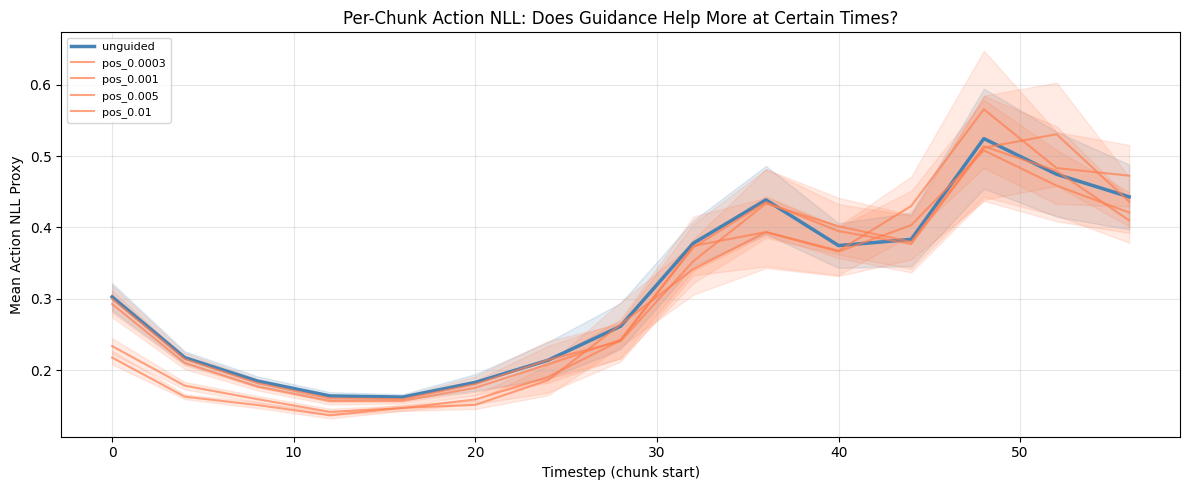

In [10]:
# ── Figure 3: Per-chunk NLL comparison ──
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

for label, r in results.items():
    per_chunk = r["per_chunk_nll"]  # (B, n_chunks)
    mean_per_chunk = per_chunk.mean(axis=0)
    sem_per_chunk = per_chunk.std(axis=0) / np.sqrt(NUM_SYNTHETIC)

    color = "steelblue" if label == "unguided" else "coral"
    lw = 2.5 if label == "unguided" else 1.5
    alpha_val = 1.0 if label == "unguided" else 0.7

    chunks_x = np.arange(len(mean_per_chunk)) * NLL_CHUNK_SIZE
    ax.plot(chunks_x, mean_per_chunk, label=label, color=color, lw=lw, alpha=alpha_val)
    ax.fill_between(chunks_x, mean_per_chunk - sem_per_chunk,
                    mean_per_chunk + sem_per_chunk, alpha=0.15, color=color)

ax.set_xlabel("Timestep (chunk start)")
ax.set_ylabel("Mean Action NLL Proxy")
ax.set_title("Per-Chunk Action NLL: Does Guidance Help More at Certain Times?")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

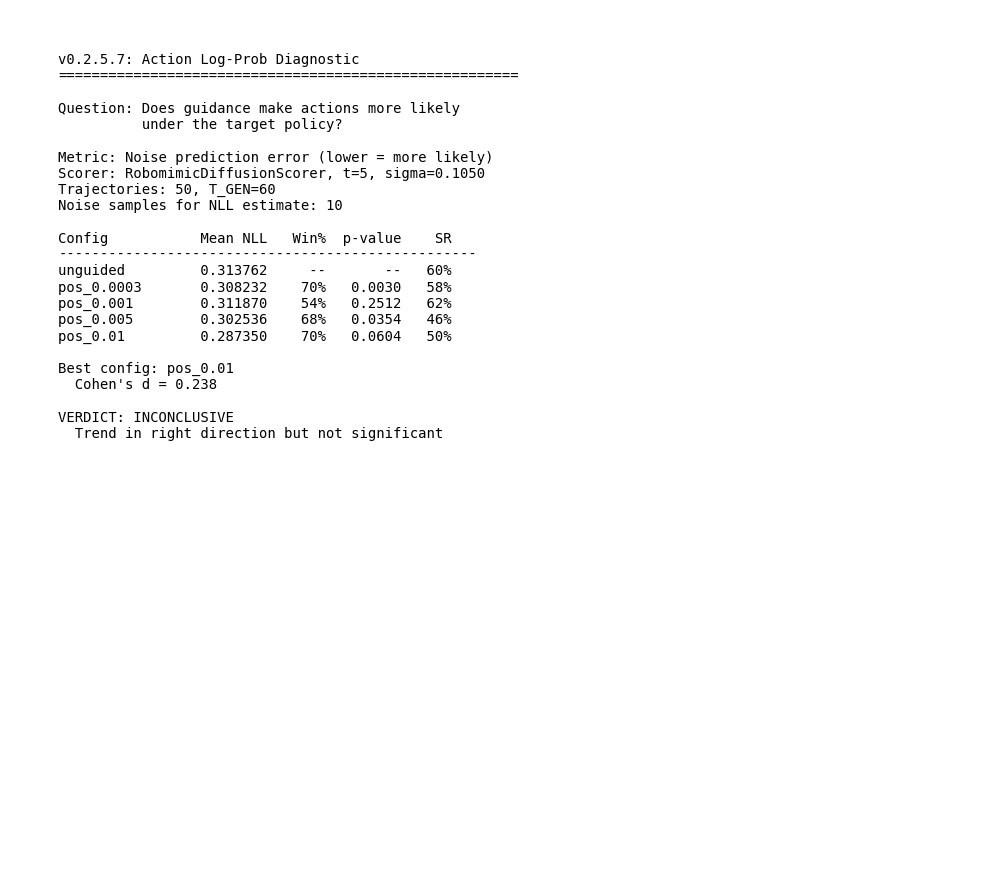

In [11]:
# ── Figure 4: Summary ──
fig, ax = plt.subplots(1, 1, figsize=(10, 9))
ax.axis("off")

lines = [
    "v0.2.5.7: Action Log-Prob Diagnostic",
    "=" * 55,
    "",
    "Question: Does guidance make actions more likely",
    "          under the target policy?",
    "",
    f"Metric: Noise prediction error (lower = more likely)",
    f"Scorer: RobomimicDiffusionScorer, t={SCORE_TIMESTEP}, sigma={target_scorer.sigma:.4f}",
    f"Trajectories: {NUM_SYNTHETIC}, T_GEN={T_GEN}",
    f"Noise samples for NLL estimate: {N_NOISE_SAMPLES}",
    "",
]

lines.append(f"{'Config':<14} {'Mean NLL':>10} {'Win%':>6} {'p-value':>8} {'SR':>5}")
lines.append("-" * 50)

for label, r in results.items():
    if label == "unguided":
        lines.append(f"{label:<14} {r['mean_nll']:>10.6f} {'--':>6} {'--':>8} {r['synth_sr']*100:>4.0f}%")
    else:
        diff = unguided_nll - r["per_traj_nll"]
        win_pct = np.mean(diff > 0) * 100
        _, p_one = stats.wilcoxon(unguided_nll, r["per_traj_nll"], alternative='greater')
        lines.append(f"{label:<14} {r['mean_nll']:>10.6f} {win_pct:>5.0f}% {p_one:>8.4f} {r['synth_sr']*100:>4.0f}%")

lines += [
    "",
    f"Best config: {best_label}",
    f"  Cohen's d = {cohens_d:.3f}",
    "",
]

# Verdict
best_win = np.mean((unguided_nll - results[best_label]["per_traj_nll"]) > 0) * 100
_, best_p = stats.wilcoxon(unguided_nll, results[best_label]["per_traj_nll"], alternative='greater')

if best_p < 0.05 and best_win > 70:
    lines.append("VERDICT: GUIDANCE WORKS")
    lines.append(f"  Actions are significantly more likely under target")
    lines.append(f"  (p={best_p:.4f}, {best_win:.0f}% win rate)")
elif best_p < 0.05:
    lines.append("VERDICT: PARTIAL")
    lines.append(f"  Statistically significant but win rate < 70%")
elif best_win > 50:
    lines.append("VERDICT: INCONCLUSIVE")
    lines.append(f"  Trend in right direction but not significant")
else:
    lines.append("VERDICT: GUIDANCE NOT WORKING")
    lines.append(f"  No evidence that guidance improves action likelihood")

ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes,
        fontsize=10, verticalalignment="top", fontfamily="monospace")
plt.tight_layout()
plt.show()